In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file='telecom_customer_churn.csv'

df=pd.read_csv(file)

In [3]:
df=df.drop(columns=['customerID'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Text(0.5, 0.98, 'Analysis of Features of IBM Churn Dataset')

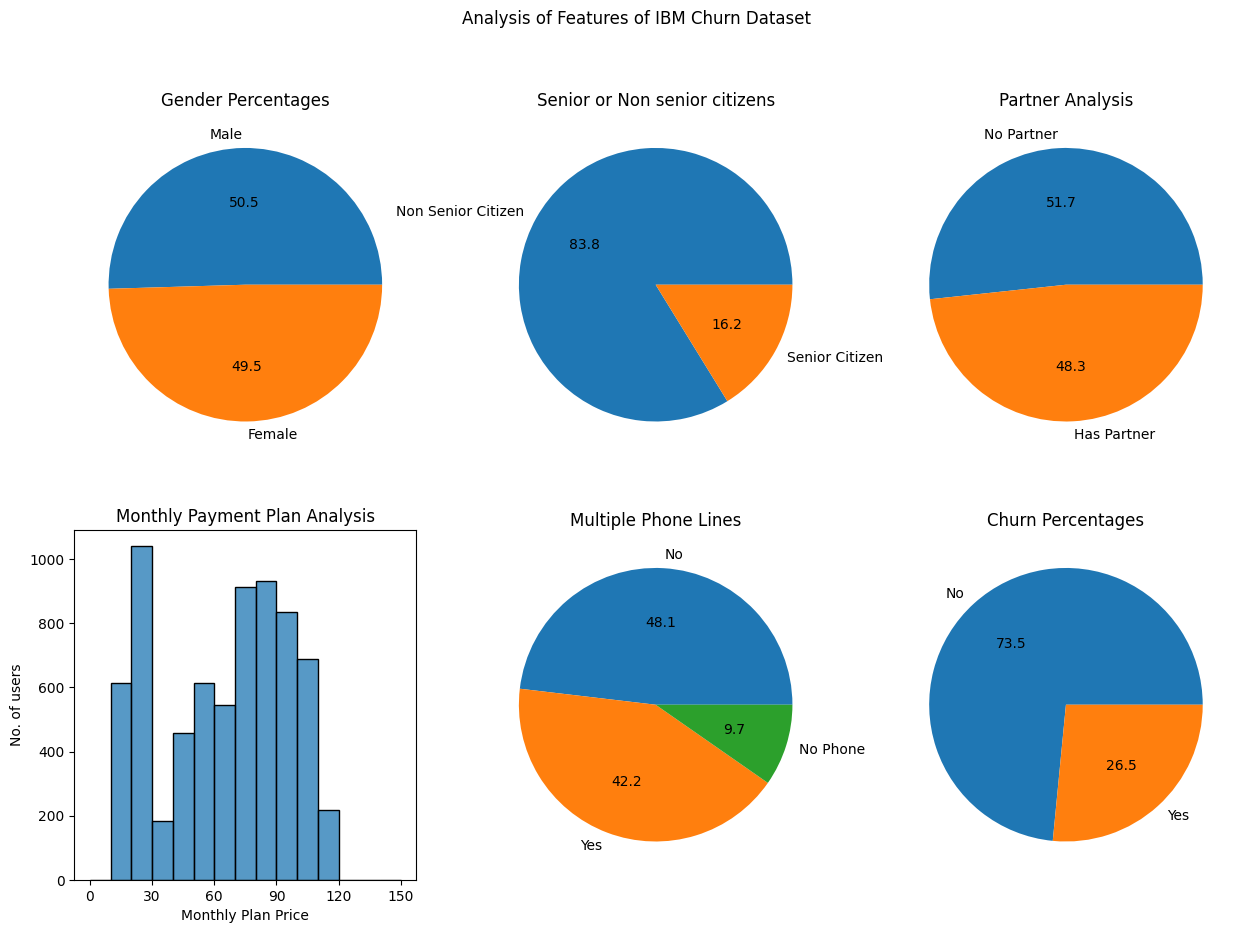

In [5]:
fig,axes=plt.subplots(nrows=2, ncols=3, figsize=(15,10))

axes[0,0].pie(df['gender'].value_counts(), autopct='%1.1f',labels=['Male','Female'])
axes[0,0].set_title('Gender Percentages')
axes[0,1].pie(df['SeniorCitizen'].value_counts(), autopct='%1.1f', labels=['Non Senior Citizen','Senior Citizen'])
axes[0,1].set_title('Senior or Non senior citizens')
axes[0,2].pie(df['Partner'].value_counts(), autopct='%1.1f', labels=['No Partner', 'Has Partner'])
axes[0,2].set_title('Partner Analysis')

sns.histplot(df['MonthlyCharges'],bins=range(0,151,10),ax=axes[1,0])
axes[1,0].set_xlabel('Monthly Plan Price')
axes[1,0].set_ylabel('No. of users')
axes[1,0].set_xticks(range(0,151,30))
axes[1,0].set_title('Monthly Payment Plan Analysis')

axes[1,1].pie(df['MultipleLines'].value_counts(), autopct='%1.1f', labels=['No','Yes','No Phone'])
axes[1,1].set_title('Multiple Phone Lines')

axes[1,2].pie(df['Churn'].value_counts(),autopct='%1.1f', labels=df['Churn'].value_counts().index)
axes[1,2].set_title('Churn Percentages')

fig.suptitle('Analysis of Features of IBM Churn Dataset')

In [6]:
df['gender']=df['gender'].map({'Female':0,'Male':1})

In [7]:
df['has_partner']=df['Partner'].map({'Yes':1,'No':0})

In [8]:
df.drop(columns=['Partner'],inplace=True)

In [9]:
df['has_dependents']=df['Dependents'].map({'Yes':1,'No':0})

In [10]:
df.drop(columns=['Dependents'],inplace=True)

In [11]:
df['has_phoneservice']=df['PhoneService'].map({'Yes':1,'No':0})

In [12]:
df.drop(columns=['PhoneService'],inplace=True)

In [13]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [14]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['has_multiplelines'] = df['MultipleLines'].map({'No': 0, 'Yes': 1})

In [15]:
df.drop(columns=['MultipleLines'],inplace=True)

In [16]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [17]:
df['internet_service_encoded'] = df['InternetService'].map({
    'No': 0, 
    'DSL': 1, 
    'Fiber optic': 2
})

In [18]:
df.drop(columns=['InternetService'],inplace=True)

In [19]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [20]:
df['is_automatic']=df['PaymentMethod'].str.contains('automatic').astype(int)

In [21]:
df['OnlineSecurity']

0        No
1       Yes
2       Yes
3       Yes
4        No
       ... 
7038    Yes
7039     No
7040    Yes
7041     No
7042    Yes
Name: OnlineSecurity, Length: 7043, dtype: str

In [22]:
# List of the 6 core internet add-on services
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many times a user has 'Yes' across these columns
df['Product_Count'] = (df[addons] == 'Yes').sum(axis=1)

# Calculate the churn rate for users with 0, 1, 2... up to 6 services
density_churn = df.groupby('Product_Count')['Churn'].value_counts(normalize=True).unstack() * 100
print(density_churn)

Churn                 No        Yes
Product_Count                      
0              78.593961  21.406039
1              54.244306  45.755694
2              64.181994  35.818006
3              72.629696  27.370304
4              77.699531  22.300469
5              87.565674  12.434326
6              94.718310   5.281690


In [23]:
# 1. Capture the high-risk zone (1 to 3 products)
df['Is_High_Risk_Integration'] = df['Product_Count'].isin([1, 2, 3]).astype(int)

# 2. Capture the ultimate ecosystem lock-in (5 or 6 products)
df['Is_Fully_Integrated'] = (df['Product_Count'] >= 5).astype(int)

In [24]:
df['Is_High_Risk_Integration'].value_counts()

Is_High_Risk_Integration
0    3926
1    3117
Name: count, dtype: int64

In [25]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [26]:
df['PaperlessBilling'].value_counts(normalize=True)

'''
60% of the people prefer paperless bill, while 40% prefer the digital bill
'''

'\n60% of the people prefer paperless bill, while 40% prefer the digital bill\n'

In [27]:
df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True)

'''
Churn is higher in those who prefer paperless billing, as they might search for replacements digitally
where as those who prefer the billing delivered, they might not be searching actively for the better subscription
leading to lower churns overall 
'''

'\nChurn is higher in those who prefer paperless billing, as they might search for replacements digitally\nwhere as those who prefer the billing delivered, they might not be searching actively for the better subscription\nleading to lower churns overall \n'

In [28]:
df['MonthlyCharges']

0        29.85
1        56.95
2        53.85
3        42.30
4        70.70
         ...  
7038     84.80
7039    103.20
7040     29.60
7041     74.40
7042    105.65
Name: MonthlyCharges, Length: 7043, dtype: float64

In [29]:
# Check the raw, unmerged churn distribution for OnlineSecurity
verification_table = df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack() * 100
print(verification_table)

df['Mod_Security']=df['OnlineSecurity'].map({'No':0,'Yes':1,'No internet service':0})
df['Mod_Security'].value_counts()

verification_table = df.groupby('Mod_Security')['Churn'].value_counts(normalize=True).unstack() * 100
print(verification_table)

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
Churn                No        Yes
Mod_Security                      
0             68.670382  31.329618
1             85.388806  14.611194


<Axes: ylabel='MonthlyCharges'>

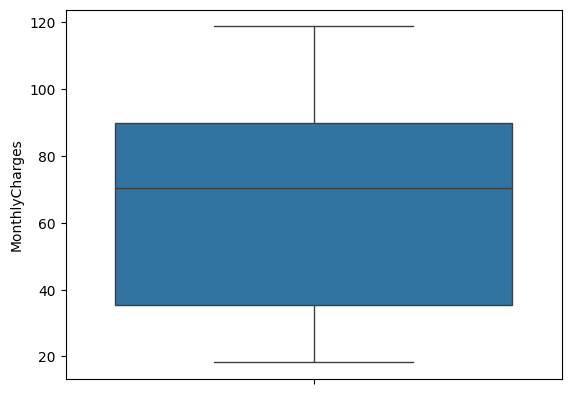

In [30]:
sns.boxplot(df['MonthlyCharges'])

<Axes: ylabel='MonthlyCharges'>

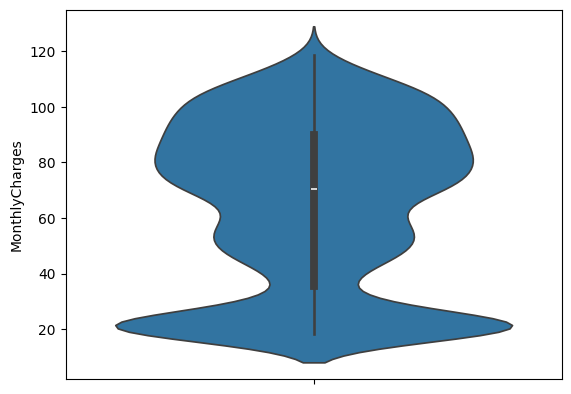

In [31]:
sns.violinplot(df['MonthlyCharges'])

In [32]:
df[df['TotalCharges']==' ']['MonthlyCharges']

488     52.55
753     20.25
936     80.85
1082    25.75
1340    56.05
3331    19.85
3826    25.35
4380    20.00
5218    19.70
6670    73.35
6754    61.90
Name: MonthlyCharges, dtype: float64

In [33]:
df[df['TotalCharges']==' ']['MonthlyCharges']

488     52.55
753     20.25
936     80.85
1082    25.75
1340    56.05
3331    19.85
3826    25.35
4380    20.00
5218    19.70
6670    73.35
6754    61.90
Name: MonthlyCharges, dtype: float64

In [34]:
df.loc[df['TotalCharges'] == ' ', 'TotalCharges'] = df[df['TotalCharges'] == ' ']['MonthlyCharges'].astype(str)

In [35]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [36]:
values=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for value in values:

    df[value]=df[value].map({"No":-1,'Yes':1,"No internet service":0})
